In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional

class I24DataAnalyzer:
    """
    Classe d'analyse et de préparation Machine Learning pour les données de trafic I-24.
    Prend en entrée un fichier Parquet prétraité.
    """
    
    def __init__(self, parquet_path: str):
        """
        Initialise l'analyseur.
        :param parquet_path: Chemin vers le fichier .parquet
        """
        self.parquet_path = parquet_path
        self.data = None

    def load_data(self, sample_fraction: float = 1.0, random_state: int = 42) -> pd.DataFrame:
        """
        Charge les données. Permet de ne prendre qu'une fraction de la base.
        L'échantillonnage se fait sur les véhicules (et non sur les lignes) pour 
        préserver la cohérence des séries temporelles.
        
        :param sample_fraction: Proportion de véhicules à charger (ex: 0.5 pour 50%).
        :return: DataFrame pandas.
        """
        print(f"Chargement des données depuis {self.parquet_path}...")
        df = pd.read_parquet(self.parquet_path)
        
        if sample_fraction < 1.0:
            # Identifier les véhicules uniques
            unique_vehicles = df['_id'].unique()
            # Sélectionner une fraction aléatoire de ces ID
            np.random.seed(random_state)
            sampled_ids = np.random.choice(unique_vehicles, 
                                           size=int(len(unique_vehicles) * sample_fraction), 
                                           replace=False)
            # Filtrer le dataframe
            df = df[df['_id'].isin(sampled_ids)].copy()
            print(f"Échantillonnage appliqué : {len(sampled_ids)} véhicules conservés.")
            
        self.data = df
        print(f"Données prêtes. Shape: {self.data.shape}")
        return self.data

    def get_summary_statistics(self):
        """
        Calcule et affiche les grandeurs caractéristiques objectives du dataset.
        """
        if self.data is None:
            raise ValueError("Les données doivent être chargées via load_data() au préalable.")
            
        print("\n" + "="*50)
        print("GRANDEURS CARACTÉRISTIQUES DU DATASET")
        print("="*50)
        
        df = self.data
        df_unique_veh = df.drop_duplicates(subset=['_id'])
        
        # 1. Nombre de véhicules
        print(f"Nombre de véhicules uniques : {len(df_unique_veh)}")
        
        # 2. Informations Spatiales (Voies)
        voies_actives = df[df['lane'] > 0]['lane'].unique()
        voies_actives.sort()
        print(f"\nNombre de voies actives détectées : {len(voies_actives)} (Voies: {voies_actives})")
        
        x_min, x_max = df['x_position'].min(), df['x_position'].max()
        longueur_miles = (x_max - x_min) / 5280
        print(f"Longueur du segment couvert : {longueur_miles:.2f} miles ({x_max - x_min:.0f} pieds)")
        
        # 3. Informations sur les véhicules (Tailles et Types)
        print("\nDimensions moyennes des véhicules :")
        print(f" - Longueur : {df_unique_veh['length'].mean():.2f} pieds")
        print(f" - Largeur  : {df_unique_veh['width'].mean():.2f} pieds")
        
        if 'coarse_vehicle_class' in df_unique_veh.columns:
            class_map = {0: 'Sedan', 1: 'Midsize', 2: 'Van', 3: 'Pickup', 4: 'Semi', 5: 'Truck'}
            repartition = df_unique_veh['coarse_vehicle_class'].value_counts().rename(index=class_map)
            print("\nRépartition par type de véhicule :")
            for veh_type, count in repartition.items():
                print(f" - {veh_type:<10} : {count} ({count/len(df_unique_veh)*100:.1f}%)")
        
        # 4. Informations Temporelles
        t_min, t_max = df['timestamp'].min(), df['timestamp'].max()
        duree_min = (t_max - t_min) / 60
        print(f"\nTemps de capture total : {duree_min:.2f} minutes")
        print(f"Vitesse moyenne globale du flux : {df['speed_kmh'].mean():.2f} km/h")
        print("="*50 + "\n")

    # ### MODIFICATION : Suppression de `line_color` (les couleurs sont fixées par ton ancien code)
    def plot_trajectories(self, num_vehicles: int = 1000, direction: int = 1):
        """
        Affiche le diagramme des trajectoires.
        MODIFIÉ : Utilisation d'un nuage de points coloré par la vitesse pour une lecture 
        moderne des ondes de choc, et suppression de la logique arbitraire de "leader".
        """
        if self.data is None:
            raise ValueError("Données non chargées.")

        df_dir = self.data[self.data['direction'] == direction]
        valid_lanes = [lane for lane in df_dir['lane'].unique() if lane > 0]
        valid_lanes.sort()
        
        sample_ids = df_dir['_id'].unique()[:num_vehicles]
        df_plot = df_dir[df_dir['_id'].isin(sample_ids)].copy()
        
        if df_plot.empty or len(valid_lanes) == 0:
            print("Aucune donnée ou voie valide à afficher pour cette direction.")
            return

        fig, axes = plt.subplots(nrows=len(valid_lanes), ncols=1, 
                                 figsize=(12, 4 * len(valid_lanes)), 
                                 sharex=True, sharey=True)
        
        if len(valid_lanes) == 1:
            axes = [axes]
            
        t_min_global = self.data['timestamp'].min()
        
        # --- DÉBUT MODIFICATION ---
        # 1. Ajout de la vitesse pour la colorimétrie si absente, calculée via dx/dt
        # (Note: on suppose que 'speed_kmh' existe selon ton get_summary_statistics)
        if 'speed_kmh' not in df_plot.columns:
            raise KeyError("La colonne 'speed_kmh' est requise pour le nouveau graphique.")
            
        # 2. Conversion vectorisée des unités pour éviter les boucles lentes
        df_plot['x_km'] = df_plot['x_position'] * 0.0003048
        df_plot['y_h'] = (df_plot['timestamp'] - t_min_global) / 3600.0
        
        # 3. Tracé global par voie (Scatter plot au lieu d'itérer sur chaque ID)
        # Cela permet d'utiliser une colormap sur la vitesse et d'améliorer grandement les performances
        for ax, lane in zip(axes, valid_lanes):
            df_lane = df_plot[df_plot['lane'] == lane]
            
            if df_lane.empty:
                continue
            
            # Utilisation de la vitesse pour colorer les trajectoires (Rouge = Lent, Vert = Rapide)
            sc = ax.scatter(df_lane['y_h'], df_lane['x_km'], # Inversion des axes : le temps en X est plus standard
                            c=df_lane['speed_kmh'], cmap='RdYlGn', 
                            s=1, alpha=0.5, vmin=0, vmax=120)

            ax.set_title(f"Voie {lane} - Diagramme Espace-Temps", fontsize=12)
            ax.set_ylabel("Position (km)")
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.set_facecolor('#f4f4f4') # Fond légèrement grisé pour faire ressortir les points clairs
        
        # 4. Ajout d'une barre de couleur globale
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(sc, cax=cbar_ax, label="Vitesse (km/h)")
        
        # 5. Ajustement des labels (Temps sur l'axe X)
        axes[-1].set_xlabel("Temps écoulé (heures)")
        plt.suptitle(f"Dynamique du trafic par voie (Direction {'EB' if direction==1 else 'WB'})", fontsize=16, fontweight='bold', y=0.98)
        
        plt.subplots_adjust(right=0.9) # Fait de la place pour la colorbar
        plt.show()
        # --- FIN MODIFICATION ---

    def plot_speed_distributions(self, direction: int = 1):
        """
        NOUVEAU CODE:
        Génère un diagramme en violon pour analyser la densité de probabilité 
        des vitesses par voie. Permet d'identifier la variance intra-voie.
        """
        import seaborn as sns
        
        if self.data is None or 'speed_kmh' not in self.data.columns:
            raise ValueError("Données non chargées ou vitesse manquante.")
            
        df_dir = self.data[(self.data['direction'] == direction) & (self.data['lane'] > 0)]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        sns.violinplot(x='lane', y='speed_kmh', data=df_dir, 
                       inner='quartile', palette='mako', ax=ax, density_norm='width')
        
        ax.set_title(f"Distribution des vitesses par voie (Direction {'EB' if direction==1 else 'WB'})", fontsize=14, fontweight='bold')
        ax.set_xlabel("Voie", fontsize=12)
        ax.set_ylabel("Vitesse instantanée (km/h)", fontsize=12)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Esthétique
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    def plot_fleet_composition_by_lane(self, direction: int = 1):
        """
        NOUVEAU CODE:
        Génère un graphique à barres empilées montrant la répartition des types 
        de véhicules pour chaque voie. Permet d'analyser la ségrégation spatiale du fret.
        """
        import seaborn as sns # Recommandé pour des palettes modernes
        
        if self.data is None or 'coarse_vehicle_class' not in self.data.columns:
            raise ValueError("Données non chargées ou classe de véhicule manquante.")
            
        df_dir = self.data[(self.data['direction'] == direction) & (self.data['lane'] > 0)]
        
        # On ne garde qu'une occurrence par véhicule pour ne pas biaiser par le temps de présence
        df_unique = df_dir.drop_duplicates(subset=['_id'])
        
        class_map = {0: 'Sedan', 1: 'Midsize', 2: 'Van', 3: 'Pickup', 4: 'Semi', 5: 'Truck'}
        df_unique['vehicle_type'] = df_unique['coarse_vehicle_class'].map(class_map)
        
        # Calcul des pourcentages
        cross_tab = pd.crosstab(df_unique['lane'], df_unique['vehicle_type'], normalize='index') * 100
        
        # Tracé
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = sns.color_palette("husl", len(class_map))
        
        cross_tab.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=1.2)
        
        ax.set_title(f"Composition de la flotte par voie (Direction {'EB' if direction==1 else 'WB'})", fontsize=14, fontweight='bold')
        ax.set_xlabel("Voie (1 = HOV/Gauche, 4+ = Droite)", fontsize=12)
        ax.set_ylabel("Proportion des véhicules (%)", fontsize=12)
        ax.legend(title="Type de véhicule", bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Esthétique moderne
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def prepare_for_ml(self, target_col: str = 'speed_kmh', 
                       features: Optional[List[str]] = None) -> Tuple[pd.DataFrame, pd.Series]:
        """
        Isole et prépare les données pour l'apprentissage automatique.
        Sépare la matrice de caractéristiques (X) et la variable cible (y).
        
        :param target_col: La colonne à prédire (ex: la vitesse 'speed_kmh').
        :param features: Liste explicite des variables prédictives à utiliser.
                         Si None, utilise une liste pertinente par défaut.
        :return: (X, y) prêts pour scikit-learn ou PyTorch.
        """
        if self.data is None:
            raise ValueError("Données non chargées.")
            
        df_ml = self.data.copy()
        
        # Exclure les valeurs manquantes sur la cible
        df_ml = df_ml.dropna(subset=[target_col])
        
        # Définition des features par défaut si non spécifiées
        if features is None:
            features = ['x_position', 'y_position', 'lane', 'length', 'width', 'coarse_vehicle_class']
            
        # Vérification de l'existence des colonnes
        missing_cols = [col for col in features + [target_col] if col not in df_ml.columns]
        if missing_cols:
            raise KeyError(f"Colonnes manquantes dans le dataset : {missing_cols}")
            
        X = df_ml[features]
        y = df_ml[target_col]
        
        print(f"Préparation ML terminée : {X.shape[0]} échantillons, {X.shape[1]} features.")
        return X, y

Chargement des données depuis 637b023440527bf2daa5932f_ready.parquet...
Données prêtes. Shape: (409270, 10)

GRANDEURS CARACTÉRISTIQUES DU DATASET
Nombre de véhicules uniques : 2673

Nombre de voies actives détectées : 4 (Voies: [1 2 3 4])
Longueur du segment couvert : 4.11 miles (21683 pieds)

Dimensions moyennes des véhicules :
 - Longueur : 29.67 pieds
 - Largeur  : 7.47 pieds

Répartition par type de véhicule :
 - Midsize    : 1227 (45.9%)
 - Sedan      : 800 (29.9%)
 - Semi       : 498 (18.6%)
 - Pickup     : 94 (3.5%)
 - Van        : 41 (1.5%)
 - Truck      : 13 (0.5%)

Temps de capture total : 6.06 minutes
Vitesse moyenne globale du flux : 107.02 km/h



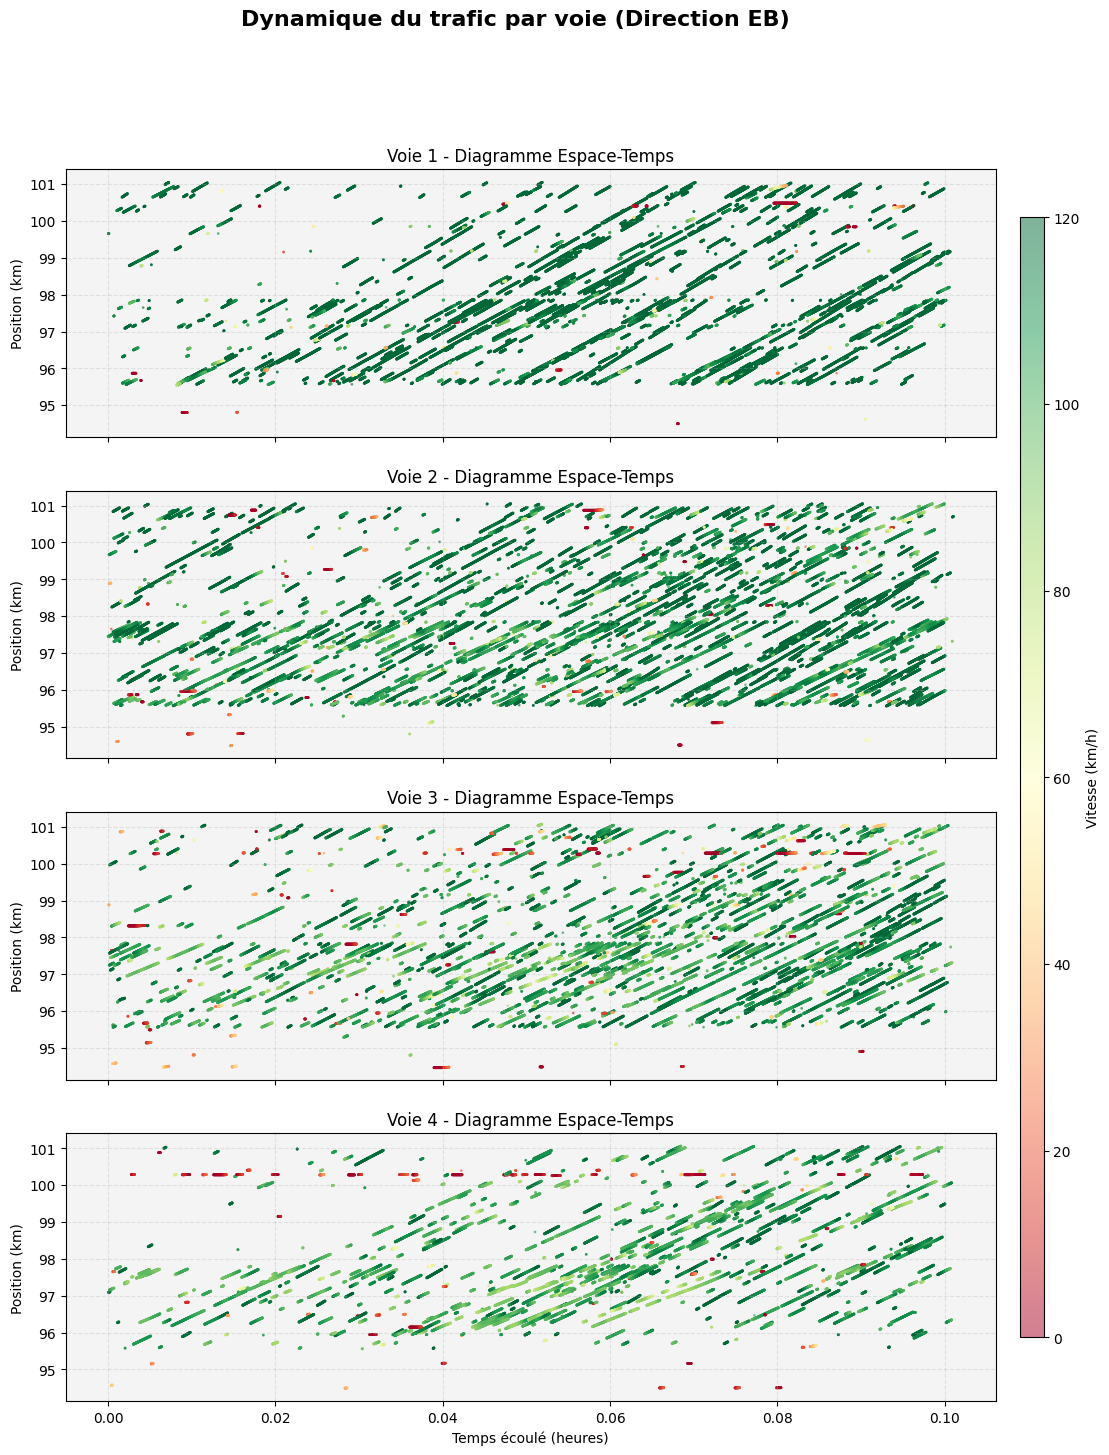

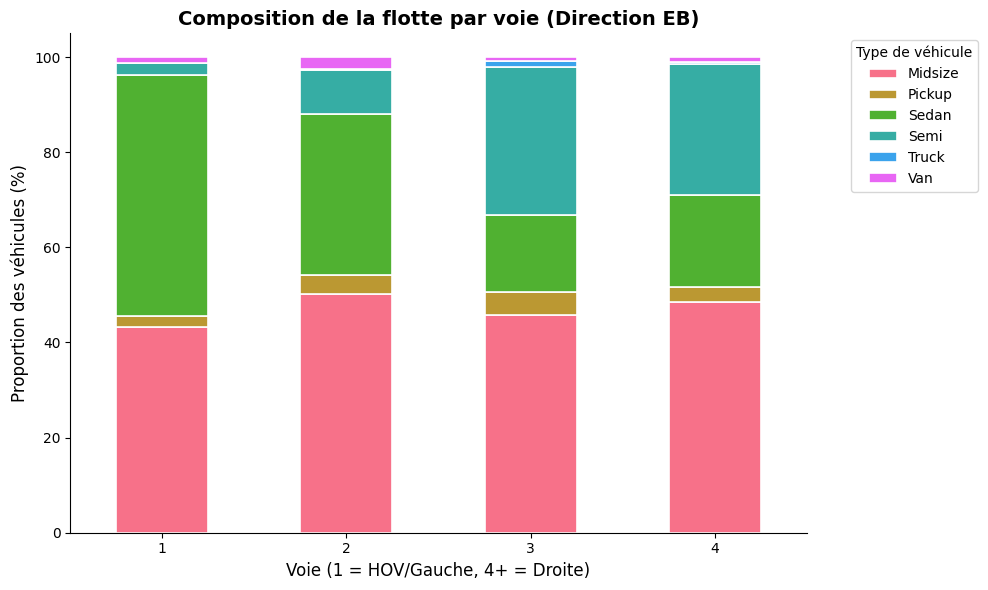

C:\Users\charl\AppData\Local\Temp\ipykernel_7164\1345883636.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='lane', y='speed_kmh', data=df_dir,


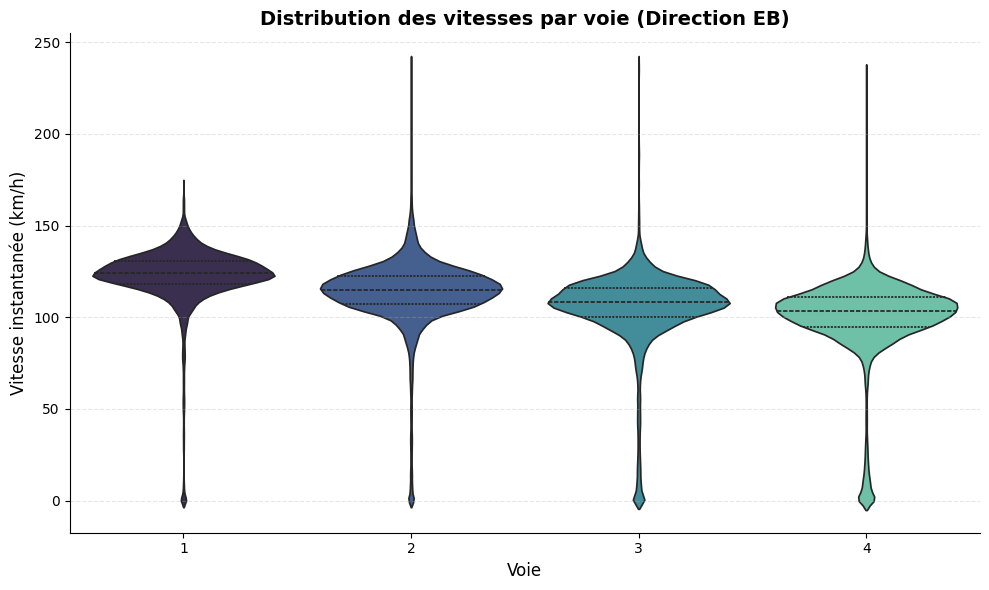

Préparation ML terminée : 409270 échantillons, 4 features.
Pipeline d'analyse terminé. X et y sont prêts.


In [4]:
# 1. Instanciation avec le chemin du fichier Parquet
chemin_parquet = '637b023440527bf2daa5932f_ready.parquet'
analyzer = I24DataAnalyzer(chemin_parquet)

# 2. Chargement des données 
df = analyzer.load_data(sample_fraction=1.0)

# 3. Affichage des grandeurs objectives
analyzer.get_summary_statistics()

# 4. Affichage des graphes d'analyse visuelle (incluant les nouvelles propositions)
# 4.a Diagramme Espace-Temps (Distance en X, Temps en Y)
analyzer.plot_trajectories(num_vehicles=2673, direction=1)

# 4.b Composition de la flotte par voie (Vérification de la ségrégation spatiale)
analyzer.plot_fleet_composition_by_lane(direction=1)

# 4.c Distribution fine des vitesses par voie (Violin plot)
analyzer.plot_speed_distributions(direction=1)

# 5. Extraction pure pour l'Apprentissage Automatique
X, y = analyzer.prepare_for_ml(target_col='speed_kmh', 
                               features=['lane', 'length', 'width', 'coarse_vehicle_class'])

# Prêt pour scikit-learn / XGBoost / PyTorch
print("Pipeline d'analyse terminé. X et y sont prêts.")